In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, StatePreparation
from qiskit.quantum_info import Statevector

# 1. 경로 설정 (현재 노트북의 상위 폴더를 path에 추가)
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. 모듈 임포트
from src.problem_setup import get_b_statevector, create_b_vector_gaussian
from src.solvers.hardware import run_vqe_fully_hardware_v2
print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


In [ ]:
def get_classical_poisson_solution(n_qubits, b_vec_data):
    """고전적 방법으로 푸아송 방정식의 정답(Exact Solution) 계산"""
    N = 2**n_qubits
    # 1D Poisson Matrix A (Tridiagonal: -1, 2, -1)
    diagonals = [2 * np.ones(N), -1 * np.ones(N-1), -1 * np.ones(N-1)]
    A_mat = diags(diagonals, [0, 1, -1]).toarray()
    
    # Ax = b 풀기
    try:
        x_solution = np.linalg.solve(A_mat, b_vec_data)
    except:
        x_solution = np.linalg.pinv(A_mat) @ b_vec_data
        
    # 정규화
    norm = np.linalg.norm(x_solution)
    return x_solution / norm if norm > 0 else x_solution

def align_phase(target_vec, ref_vec):
    """
    VQE 결과(target)의 전역 위상(Global Phase)을 
    정답(ref)과 일치하도록 회전 (시각화 보정용)
    """
    overlap = np.dot(ref_vec.conj(), target_vec)
    if np.abs(overlap) < 1e-10:
        return target_vec
    phase_factor = overlap / np.abs(overlap)
    return target_vec / phase_factor

def plot_comparison(m_qubits, exact_sol, vqe_state_data, fidelity):
    """결과 비교 그래프 그리기"""
    n = 2**m_qubits
    x_grid = np.linspace(0, 1, n + 2)[1:-1]
    
    # 위상 정렬 적용
    aligned_vqe = align_phase(vqe_state_data, exact_sol)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_grid, exact_sol, 'k-', linewidth=2, label='Exact Solution')
    plt.plot(x_grid, aligned_vqe.real, 'ro--', markersize=8, label=f'VQE (F={fidelity:.4f})')
    
    plt.title(f"Poisson Solver Hardware Test (n={m_qubits})")
    plt.xlabel("Position x")
    plt.ylabel("Amplitude u(x)")
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.show()

🚀 Starting Hardware Solver Test (3Q, QAOA, noisy_sim)...
-> QAOA Ansatz Created (Params: 4)
[INFO] Setting up backend for mode: noisy_sim
[INFO] Using V2 Primitives on backend: aer_simulator_from(fake_sherbrooke)
[INFO] Generating and transpiling Hadamard test circuits...

[INFO] Starting VQE Optimization (COBYLA, Backend: noisy_sim)...


/Users/Jongseok/Documents/STUDY/Quantum Computing/Q-Code/VQE-Poisson-Solver/src/solvers/hardware.py:155: OptimizeWarning: Unknown solver options: shots
  res = minimize(cost_func, initial_params, method=optimizer, options=options)


Iter 38: Cost=1.301906 (<A^2>=1.3040, Overlap=0.0021)
Optimization Complete
Final Cost: 1.226021
Final Fidelity: 0.946738


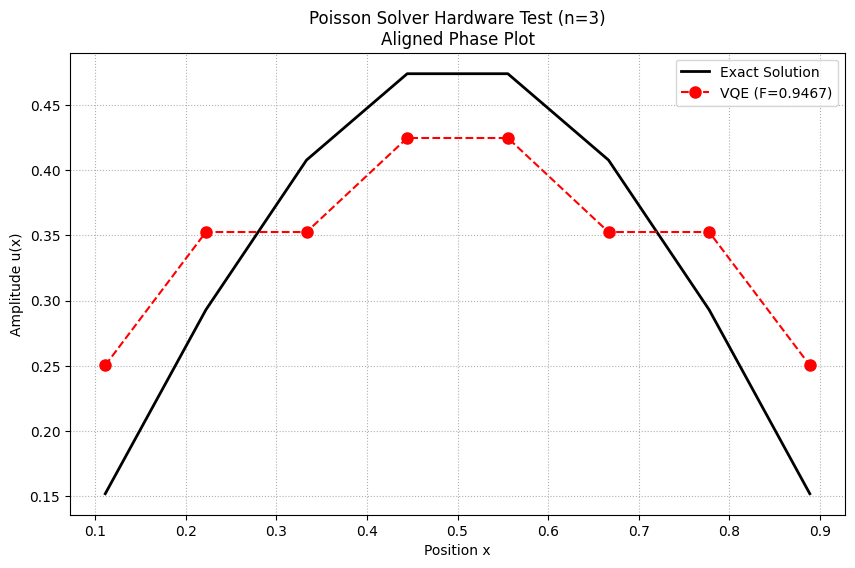

In [ ]:
# === [설정] 테스트 파라미터 ===
M_QUBITS = 3               # 큐비트 수
LAYERS = 2                 # Ansatz 레이어 수 (QAOA의 p)
BACKEND_MODE = 'noisy_sim' # 'noiseless', 'noisy_sim', 'real'
OPTIMIZER = 'COBYLA'       # 'COBYLA', 'Nelder-Mead', 'Powell', 'SLSQP'
SHOTS = 16384              # 충분한 샷 수
MAX_ITER = 2000            

# [추가됨] Ansatz 타입 선택 ('RealAmplitudes' or 'QAOA')
ANSATZ_TYPE = 'QAOA' 

print(f"🚀 Starting Hardware Solver Test ({M_QUBITS}Q, {ANSATZ_TYPE}, {BACKEND_MODE})...")

# 1. 문제 준비
from src.problem_setup import get_b_statevector, create_b_vector_gaussian
b_vec, b_data = get_b_statevector(M_QUBITS, create_b_vector_gaussian)

# 2. Ansatz 생성
from src.ansatz import create_qaoa_ansatz # 함수 임포트
from qiskit.circuit.library import RealAmplitudes

if ANSATZ_TYPE == 'QAOA':
    ansatz = create_qaoa_ansatz(M_QUBITS, layers=LAYERS)
    print(f"-> QAOA Ansatz Created (Params: {ansatz.num_parameters})")
else:
    ansatz = RealAmplitudes(M_QUBITS, entanglement='linear', reps=LAYERS)
    print(f"-> RealAmplitudes Created (Params: {ansatz.num_parameters})")

# 3. Hardware Solver용 b 회로 생성
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
b_circuit = QuantumCircuit(M_QUBITS)
b_circuit.append(StatePreparation(b_data), range(M_QUBITS))

# 4. VQE 실행
options = {'maxiter': MAX_ITER, 'tol': 1e-4, 'shots': SHOTS}

result = run_vqe_fully_hardware_v2(
    M_QUBITS, ansatz, b_circuit, 
    backend_mode=BACKEND_MODE,
    optimizer=OPTIMIZER,
    options=options
)

print("\n" + "="*40)
print("Optimization Complete")
print(f"Final Cost: {result.fun:.6f}")

# 5. 결과 분석
from qiskit.quantum_info import Statevector
final_state = Statevector(ansatz.assign_parameters(result.x))

# 고전적 정답 비교
exact_sol = get_classical_poisson_solution(M_QUBITS, b_data.real)
fidelity = np.abs(np.dot(final_state.data.conj(), exact_sol))**2

print(f"Final Fidelity: {fidelity:.6f}")
print("="*40)

# 6. 그래프 출력
plot_comparison(M_QUBITS, exact_sol, final_state.data, fidelity)